# RNA reactivity prediction using RNN
---
**Date:** 21 Feb 2026  
**Description:** Implementing a RNN for RNA reactivity prediction.

---

In [90]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import json
import pandas as pd
import numpy as np
import os

In [4]:
# Load train and test data from JSON file

train_df = pd.read_json('train.json', lines=True)
test_df = pd.read_json('test.json', lines=True)

In [97]:
train_df.head()

,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,deg_error_Mg_pH10,deg_error_pH10,deg_error_Mg_50C,deg_error_50C,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,0,id_001f94081,GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUA...,.....((((((.......)))).)).((.....((..((((((......,EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHH...,6.894,1,107,68,"[0.1359, 0.20700000000000002, 0.1633, 0.1452, ...","[0.26130000000000003, 0.38420000000000004, 0.1...","[0.2631, 0.28600000000000003, 0.0964, 0.1574, ...","[0.1501, 0.275, 0.0947, 0.18660000000000002, 0...","[0.2167, 0.34750000000000003, 0.188, 0.2124, 0...","[0.3297, 1.5693, 1.1227, 0.8686, 0.7217, 0.438...","[0.7556, 2.983, 0.2526, 1.3789, 0.637600000000...","[2.3375, 3.5060000000000002, 0.3008, 1.0108, 0...","[0.35810000000000003, 2.9683, 0.2589, 1.4552, ...","[0.6382, 3.4773, 0.9988, 1.3228, 0.78770000000..."
1,1,id_0049f53ba,GGAAAAAGCGCGCGCGGUUAGCGCGCGCUUUUGCGCGCGCUGUACC...,.....(((((((((((((((((((((((....)))))))))).)))...,EEEEESSSSSSSSSSSSSSSSSSSSSSSHHHHSSSSSSSSSSBSSS...,0.193,0,107,68,"[2.8272, 2.8272, 2.8272, 4.7343, 2.5676, 2.567...","[73705.3985, 73705.3985, 73705.3985, 73705.398...","[10.1986, 9.2418, 5.0933, 5.0933, 5.0933, 5.09...","[16.6174, 13.868, 8.1968, 8.1968, 8.1968, 8.19...","[15.4857, 7.9596, 13.3957, 5.8777, 5.8777, 5.8...","[0.0, 0.0, 0.0, 2.2965, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.947, 4.4523, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.8511, 4.0426, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7.6692, 0.0, 10.9561, 0.0, 0.0, 0.0, 0.0, 0.0..."
2,2,id_006f36f57,GGAAAGUGCUCAGAUAAGCUAAGCUCGAAUAGCAAUCGAAUAGAAU...,.....((((.((.....((((.(((.....)))..((((......)...,EEEEESSSSISSIIIIISSSSMSSSHHHHHSSSMMSSSSHHHHHHS...,8.800,1,107,68,"[0.0931, 0.13290000000000002, 0.11280000000000...","[0.1365, 0.2237, 0.1812, 0.1333, 0.1148, 0.160...","[0.17020000000000002, 0.178, 0.111, 0.091, 0.0...","[0.1033, 0.1464, 0.1126, 0.09620000000000001, ...","[0.14980000000000002, 0.1761, 0.1517, 0.116700...","[0.44820000000000004, 1.4822, 1.1819, 0.743400...","[0.2504, 1.4021000000000001, 0.9804, 0.4967000...","[2.243, 2.9361, 1.0553, 0.721, 0.6396000000000...","[0.5163, 1.6823000000000001, 1.0426, 0.7902, 0...","[0.9501000000000001, 1.7975, 1.4991, 0.8686, 0..."
3,3,id_0082d463b,GGAAAAGCGCGCGCGCGCGCGCGAAAAAGCGCGCGCGCGCGCGCGC...,......((((((((((((((((......))))))))))))))))((...,EEEEEESSSSSSSSSSSSSSSSHHHHHHSSSSSSSSSSSSSSSSSS...,0.104,0,107,68,"[3.5229, 6.0748, 3.0374, 3.0374, 3.0374, 3.037...","[73705.3985, 73705.3985, 73705.3985, 73705.398...","[11.8007, 12.7566, 5.7733, 5.7733, 5.7733, 5.7...","[121286.7181, 121286.7182, 121286.7181, 121286...","[15.3995, 8.1124, 7.7824, 7.7824, 7.7824, 7.78...","[0.0, 2.2399, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, -0.5083, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[3.4248, 6.8128, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.8365, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[7.6692, -1.3223, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0..."
4,4,id_0087940f4,GGAAAAUAUAUAAUAUAUUAUAUAAAUAUAUUAUAGAAGUAUAAUA...,.....(((((((.((((((((((((.(((((((((....)))))))...,EEEEESSSSSSSBSSSSSSSSSSSSBSSSSSSSSSHHHHSSSSSSS...,0.423,0,107,68,"[1.665, 2.1728, 2.0041, 1.2405, 0.620200000000...","[4.2139, 3.9637000000000002, 3.2467, 2.4716, 1...","[3.0942, 3.015, 2.1212, 2.0552, 0.881500000000...","[2.6717, 2.4818000000000002, 1.9919, 2.5485, 1...","[1.3285, 3.6173, 1.3057, 1.3021, 1.1507, 1.150...","[0.8267, 2.6577, 2.8481, 0.40090000000000003, ...","[2.1058, 3.138, 2.5437, 1.0932, 0.0, 0.0, 1.13...","[4.7366, 4.6243, 1.2068, 1.1538, 0.0, 0.0, 0.7...","[2.2052, 1.7947, 0.7457, 3.1233, 0.8086, 2.205...","[0.0, 5.1198, -0.3551, -0.3518, 0.0, 0.0, 0.0,..."


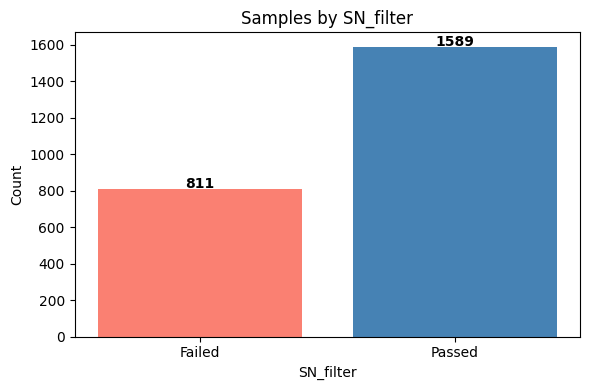

In [ ]:
# Histogram of SN_filter values (passed vs failed)

# Count passed and failed
counts = train_df['SN_filter'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Failed', 'Passed'], counts.values, color=['salmon', 'steelblue'])
plt.title('Samples by SN_filter')
plt.xlabel('SN_filter')
plt.ylabel('Count')

# Add count labels on top of bars
for i, count in enumerate(counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# One-hot encode sequences function

vocab = {'A': 0, 'C': 1, 'G': 2, 'U': 3}

def one_hot_encode(sequence):
    # Step 1: convert characters to integer indices
    indices = torch.tensor([vocab[c] for c in sequence])
    
    # Step 2: one-hot encode
    encoding = F.one_hot(indices, num_classes=4)
    
    return encoding.float()  # convert from int64 to float32 for the model

In [60]:
# Create dataset

class RNADataset(Dataset):
    def __init__(self, df):
        df = df[df['SN_filter'] == 1.0].reset_index(drop=True)
    
        # Pre-encode everything upfront
        self.sequences = torch.stack([
            one_hot_encode(seq) for seq in df['sequence'].values
        ])

        # Trim sequences to first 68 nucleotides
        self.sequences = self.sequences[:, :68, :]
    
        self.labels = torch.tensor(
            np.array(df['reactivity'].tolist(), dtype=np.float32)
        )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        reactivity = self.labels[idx]
        return sequence, reactivity

# Create dataset and dataloader
dataset = RNADataset(train_df)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [61]:
print(dataset.sequences.shape)  # Should be (num_samples, seq_length, 4)

torch.Size([1589, 68, 4])


In [62]:
class RNAModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_layers=2):
        super(RNAModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(in_features = hidden_size, out_features = 1)  # Output is a single reactivity value

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch_size, seq_length, hidden_size); discard final hidden state
        out = self.fc(out)    # (batch_size, seq_length, 1)
        return out.squeeze(-1)  # Return as (batch_size, seq_length)

In [94]:
model = RNAModel(input_size=4, hidden_size=256, num_layers=10)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch [1/100], Loss: 0.2102
Epoch [2/100], Loss: 0.1563
Epoch [3/100], Loss: 0.1538
Epoch [4/100], Loss: 0.1532
Epoch [5/100], Loss: 0.1529
Epoch [6/100], Loss: 0.1524
Epoch [7/100], Loss: 0.1532
Epoch [8/100], Loss: 0.1526
Epoch [9/100], Loss: 0.1510
Epoch [10/100], Loss: 0.1507
Epoch [11/100], Loss: 0.1495
Epoch [12/100], Loss: 0.1477
Epoch [13/100], Loss: 0.1461
Epoch [14/100], Loss: 0.1422
Epoch [15/100], Loss: 0.1411
Epoch [16/100], Loss: 0.1370
Epoch [17/100], Loss: 0.1334
Epoch [18/100], Loss: 0.1315
Epoch [19/100], Loss: 0.1263
Epoch [20/100], Loss: 0.1219
Epoch [21/100], Loss: 0.1186
Epoch [22/100], Loss: 0.1138
Epoch [23/100], Loss: 0.1116
Epoch [24/100], Loss: 0.1069
Epoch [25/100], Loss: 0.1029
Epoch [26/100], Loss: 0.0975
Epoch [27/100], Loss: 0.0937
Epoch [28/100], Loss: 0.0904
Epoch [29/100], Loss: 0.0879
Epoch [30/100], Loss: 0.0838
Epoch [31/100], Loss: 0.0796
Epoch [32/100], Loss: 0.0785
Epoch [33/100], Loss: 0.0745
Epoch [34/100], Loss: 0.0718
Epoch [35/100], Loss: 0

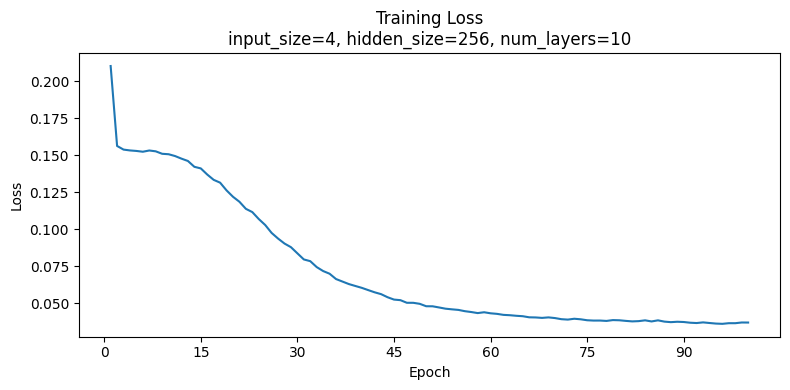

In [95]:
train_losses = []
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for sequences, reactivity in dataloader:
        # sequences:  (batch_size, 107, 4)
        # reactivity: (batch_size,)

        outputs = model(sequences)           # forward pass
        loss = criterion(outputs, reactivity) # compare predictions to labels

        optimizer.zero_grad()  # clear old gradients
        loss.backward()        # backpropagation
        optimizer.step()       # update weights

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Plot training loss curve
os.makedirs('./Figures', exist_ok=True)

# Extract info directly from the model
hidden_size = model.rnn.hidden_size
num_layers = model.rnn.num_layers
input_size = model.rnn.input_size

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), train_losses)
plt.title(f'Training Loss\ninput_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(f'./Figures/training_loss_hidden{hidden_size}_layers{num_layers}.png', dpi=150)
plt.show()